
| Nom                                 | Matricule |
|:------------------------------------| :--- |
| KAMDOM NGUETCHESSI MERVEILLE PRISCA | 23V2060 |
| YOKO AYMERICK JEFFREY               | 23U2983 |
| KENNE YEMTSA LOWEL RAYANN           | 23U2477 |

# TP5 - SVM *From Scratch* — Classification Multi-Classes sur MNIST

---

Ce notebook documente et explique l'implémentation **complète from scratch** d'un SVM à noyau RBF avec l'algorithme d'optimisation **SMO (Sequential Minimal Optimization)**, appliqué à la classification multi-classes du dataset **MNIST** (chiffres manuscrits 0–9).

### Architecture globale du projet


### Table des matières
1. [Rappels théoriques sur le SVM](#1)
2. [Pré-traitement : StandardScaler from scratch](#2)
3. [Le noyau RBF](#3)
4. [L'algorithme SMO (cœur du SVM)](#4)
5. [Classification multi-classes : One-vs-One (OvO)](#5)
6. [Chargement des données MNIST](#6)
7. [Entraînement et évaluation](#7)
8. [Bilan et pistes d'amélioration](#8)

## 0. Imports

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import itertools

try:
    import matplotlib.pyplot as plt
    plt.style.use('seaborn-v0_8-whitegrid')
    HAS_MATPLOTLIB = True
except ModuleNotFoundError:
    plt = None
    HAS_MATPLOTLIB = False
    print("[INFO] matplotlib n'est pas installe: les cellules de graphes seront ignorees.")

print("Imports OK")


Imports OK


<a id='1'></a>
## 1. Rappels théoriques sur le SVM

### 1.1 L'idée fondamentale

Un **Support Vector Machine** (SVM) cherche l'**hyperplan à marge maximale** qui sépare deux classes. Formellement, pour des données $(x_i, y_i)$ avec $y_i \in \{-1, +1\}$, on résout :

$$\min_{w, b} \frac{1}{2}\|w\|^2 \quad \text{s.c.} \quad y_i(w \cdot x_i + b) \geq 1, \; \forall i$$

### 1.2 Le SVM à marge souple (C-SVM)

En pratique, les données ne sont pas linéairement séparables. On introduit des **variables de relâchement** $\xi_i \geq 0$ et un hyperparamètre $C$ qui contrôle le compromis entre la marge et les erreurs de classification :

$$\min_{w, b, \xi} \frac{1}{2}\|w\|^2 + C \sum_i \xi_i \quad \text{s.c.} \quad y_i(w \cdot x_i + b) \geq 1 - \xi_i, \; \xi_i \geq 0$$

| Valeur de C | Comportement |
|:-----------:|:------------:|
| $C$ grand | Marge stricte, faible tolérance aux erreurs (risque sur-apprentissage) |
| $C$ petit | Marge large, plus tolérant (risque sous-apprentissage) |

### 1.3 La formulation duale et les multiplicateurs de Lagrange

Par dualité de Lagrange, le problème se réécrit en termes de **multiplicateurs** $\lambda_i \geq 0$ :

$$\max_{\lambda} \sum_i \lambda_i - \frac{1}{2} \sum_{i,j} \lambda_i \lambda_j y_i y_j K(x_i, x_j) \quad \text{s.c.} \quad 0 \leq \lambda_i \leq C, \; \sum_i \lambda_i y_i = 0$$

La **fonction de décision** devient alors :

$$f(x) = \sum_{i \in SV} \lambda_i y_i K(x_i, x) + b$$

Seuls les points avec $\lambda_i > 0$ (les **vecteurs supports**) contribuent à $f$.

### 1.4 Les conditions KKT

Les conditions d'optimalité (KKT) indiquent qu'à l'optimum :
- Si $\lambda_i = 0$ : le point est bien classifié, au-delà de la marge
- Si $0 < \lambda_i < C$ : le point est sur la marge (vecteur support)
- Si $\lambda_i = C$ : le point est dans la marge ou mal classifié

Ces conditions sont **vérifiées à chaque itération de SMO** pour détecter quelle paire $(\lambda_i, \lambda_j)$ optimiser.

<a id='2'></a>
## 2. Pré-traitement : StandardScaler from scratch

Avant d'entraîner le SVM, il est **crucial de normaliser les données**. Le noyau RBF mesure des distances euclidiennes — si une feature a une variance 1000x plus grande qu'une autre, elle dominera toutes les distances et faussera le modèle.

La **standardisation** transforme chaque feature $j$ de sorte qu'elle ait :
- Moyenne = 0
- Écart-type = 1

$$x'_{ij} = \frac{x_{ij} - \mu_j}{\sigma_j}$$

>  **Règle d'or** : On calcule $\mu$ et $\sigma$ **uniquement sur le train set**, puis on les applique au test set. Cela évite toute fuite d'information (*data leakage*).

In [2]:
class StandardScalerScratch:
    """Standardisation simple: (X - moyenne) / ecart-type."""

    def __init__(self, epsilon=1e-8):
        # epsilon évite la division par zéro pour les features constantes
        self.epsilon = epsilon
        self.mean_ = None
        self.std_ = None

    def fit(self, X):
        """Calcule μ et σ sur les données d'entraînement uniquement."""
        self.mean_ = np.mean(X, axis=0)  # shape: (n_features,)
        self.std_ = np.std(X, axis=0)
        # Si une feature est constante (σ=0), on met σ=1 pour éviter 0/0
        self.std_[self.std_ < self.epsilon] = 1.0
        return self

    def transform(self, X):
        """Applique la standardisation avec les paramètres ajustés."""
        if self.mean_ is None or self.std_ is None:
            raise RuntimeError("Le scaler doit etre entraine avec fit() avant transform().")
        return (X - self.mean_) / self.std_

    def fit_transform(self, X):
        """Raccourci: fit puis transform en une seule étape."""
        return self.fit(X).transform(X)


# --- Démonstration ---
X_demo = np.array([[100., 0.1],
                   [200., 0.2],
                   [300., 0.3]])

scaler_demo = StandardScalerScratch()
X_scaled_demo = scaler_demo.fit_transform(X_demo)

print("Données brutes:")
print(X_demo)
print(f"\nMoyenne par feature:  {scaler_demo.mean_}")
print(f"Écart-type par feature: {np.array2string(scaler_demo.std_, precision=4)}")
print(f"\nDonnées standardisées:")
print(X_scaled_demo)
print(f"\nVérification — Moyenne après scaling: {X_scaled_demo.mean(axis=0)}")
print(f"Vérification — Std après scaling:    {X_scaled_demo.std(axis=0)}")

Données brutes:
[[1.e+02 1.e-01]
 [2.e+02 2.e-01]
 [3.e+02 3.e-01]]

Moyenne par feature:  [200.    0.2]
Écart-type par feature: [8.165e+01 8.165e-02]

Données standardisées:
[[-1.22474487e+00 -1.22474487e+00]
 [ 0.00000000e+00 -3.39934989e-16]
 [ 1.22474487e+00  1.22474487e+00]]

Vérification — Moyenne après scaling: [ 0.00000000e+00 -5.18104078e-16]
Vérification — Std après scaling:    [1. 1.]


### 2.1 Visualisation de la standardisation

Le SVM avec noyau RBF dépend directement des distances entre points. Si une feature a une échelle beaucoup plus grande qu'une autre, elle domine la distance euclidienne et donc le noyau. Le graphique suivant montre que la standardisation remet les deux features de démonstration sur une échelle comparable.


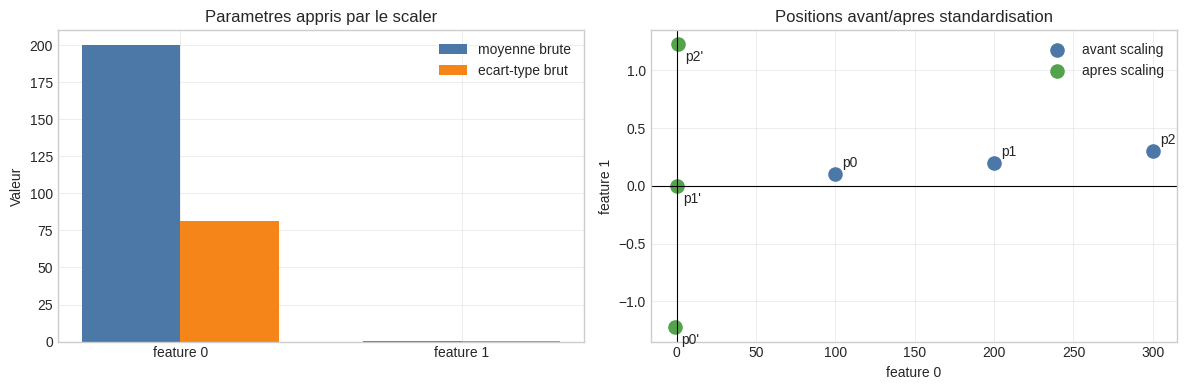

In [3]:
if not HAS_MATPLOTLIB:
    print("Graphe ignore: installez matplotlib pour afficher cette visualisation.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    feature_names = ["feature 0", "feature 1"]
    x_positions = np.arange(len(feature_names))
    width = 0.35

    axes[0].bar(x_positions - width / 2, scaler_demo.mean_, width, label="moyenne brute", color="#4c78a8")
    axes[0].bar(x_positions + width / 2, scaler_demo.std_, width, label="ecart-type brut", color="#f58518")
    axes[0].set_xticks(x_positions)
    axes[0].set_xticklabels(feature_names)
    axes[0].set_title("Parametres appris par le scaler")
    axes[0].set_ylabel("Valeur")
    axes[0].legend()

    axes[1].scatter(X_demo[:, 0], X_demo[:, 1], s=90, label="avant scaling", color="#4c78a8")
    axes[1].scatter(X_scaled_demo[:, 0], X_scaled_demo[:, 1], s=90, label="apres scaling", color="#54a24b")
    for idx, (x_raw, x_scaled) in enumerate(zip(X_demo, X_scaled_demo)):
        axes[1].annotate(f"p{idx}", xy=x_raw, xytext=(5, 5), textcoords="offset points")
        axes[1].annotate(f"p{idx}'", xy=x_scaled, xytext=(5, -12), textcoords="offset points")
    axes[1].axhline(0, color="black", linewidth=0.8)
    axes[1].axvline(0, color="black", linewidth=0.8)
    axes[1].set_title("Positions avant/apres standardisation")
    axes[1].set_xlabel("feature 0")
    axes[1].set_ylabel("feature 1")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


<a id='3'></a>
## 3. Le noyau RBF (Radial Basis Function)

### 3.1 Pourquoi un noyau ?

Un SVM linéaire ne peut séparer que des données **linéairement séparables**. Pour des problèmes complexes comme MNIST, on utilise l'**astuce du noyau** (*kernel trick*) : on projette implicitement les données dans un espace de dimension très grande (voire infinie) où elles deviennent séparables.

Le noyau $K(x_i, x_j) = \langle \phi(x_i), \phi(x_j) \rangle$ calcule le **produit scalaire dans l'espace projeté**, sans jamais calculer $\phi$ explicitement.

### 3.2 Le noyau RBF

$$K_{RBF}(x_i, x_j) = \exp\left(-\gamma \|x_i - x_j\|^2\right)$$

| Paramètre | Rôle |
|:---------:|:----:|
| $\gamma$ grand | Frontière très "locale", risque de sur-apprentissage |
| $\gamma$ petit | Frontière lisse, plus généralisable |

### 3.3 Calcul vectorisé de la matrice de Gram

Calculer $K[i,j]$ pour toute paire $(i,j)$ naïvement est en $O(n^2 \cdot d)$. On peut l'accélérer avec l'identité :

$$\|x_i - x_j\|^2 = \|x_i\|^2 + \|x_j\|^2 - 2 x_i \cdot x_j$$

Ce qui s'implémente avec des opérations matricielles vectorisées NumPy.

In [4]:
class NoyauRBF:
    def __init__(self, gamma=0.01):
        self.gamma = gamma

    def calculer(self, x1, x2):
        """Calcule K(x1, x2) pour deux vecteurs individuels."""
        distance_carre = np.linalg.norm(x1 - x2) ** 2
        return np.exp(-self.gamma * distance_carre)

    def matrice(self, X1, X2=None):
        """
        Calcule la matrice de Gram K[i,j] = exp(-gamma * ||X1[i] - X2[j]||²)
        de façon vectorisée avec l'identité ||a-b||² = ||a||² + ||b||² - 2<a,b>.

        Complexité: O(n² · d) mais sans boucle Python explicite.
        np.maximum(..., 0) corrige les erreurs numériques de virgule flottante
        qui pourraient donner de petites valeurs négatives.
        """
        if X2 is None:
            X2 = X1  # Matrice de Gram symétrique (phase d'entraînement)

        X1_norm = np.sum(X1 ** 2, axis=1).reshape(-1, 1)  # shape: (n1, 1)
        X2_norm = np.sum(X2 ** 2, axis=1).reshape(1, -1)  # shape: (1, n2)
        distances_carrees = X1_norm + X2_norm - 2.0 * (X1 @ X2.T)  # broadcasting
        distances_carrees = np.maximum(distances_carrees, 0.0)  # sécurité numérique
        return np.exp(-self.gamma * distances_carrees)


# --- Démonstration ---
noyau_demo = NoyauRBF(gamma=0.5)

# Cas extrêmes du noyau RBF
x = np.array([1.0, 0.0])
print(f"K(x, x)      = {noyau_demo.calculer(x, x):.4f}  (distance=0 → K=1, toujours)")
print(f"K(x, -x)     = {noyau_demo.calculer(x, -x):.6f}  (points éloignés → K≈0)")

# Matrice de Gram sur un petit exemple
X_demo2 = np.array([[0., 0.], [1., 0.], [0., 1.]])
K = noyau_demo.matrice(X_demo2)
print(f"\nMatrice de Gram (3x3):")
print(np.round(K, 4))
print("→ Diagonale = 1.0 (chaque point est identique à lui-même)")
print("→ Symétrique (K[i,j] = K[j,i])")

K(x, x)      = 1.0000  (distance=0 → K=1, toujours)
K(x, -x)     = 0.135335  (points éloignés → K≈0)

Matrice de Gram (3x3):
[[1.     0.6065 0.6065]
 [0.6065 1.     0.3679]
 [0.6065 0.3679 1.    ]]
→ Diagonale = 1.0 (chaque point est identique à lui-même)
→ Symétrique (K[i,j] = K[j,i])


### 3.2 Visualisation du noyau RBF

Le paramètre `gamma` contrôle la notion de voisinage. Quand `gamma` est petit, deux points éloignés restent partiellement similaires. Quand `gamma` est grand, la similarité tombe très vite vers zéro. C'est un hyperparamètre important parce qu'il influence directement la forme de la frontière de décision.


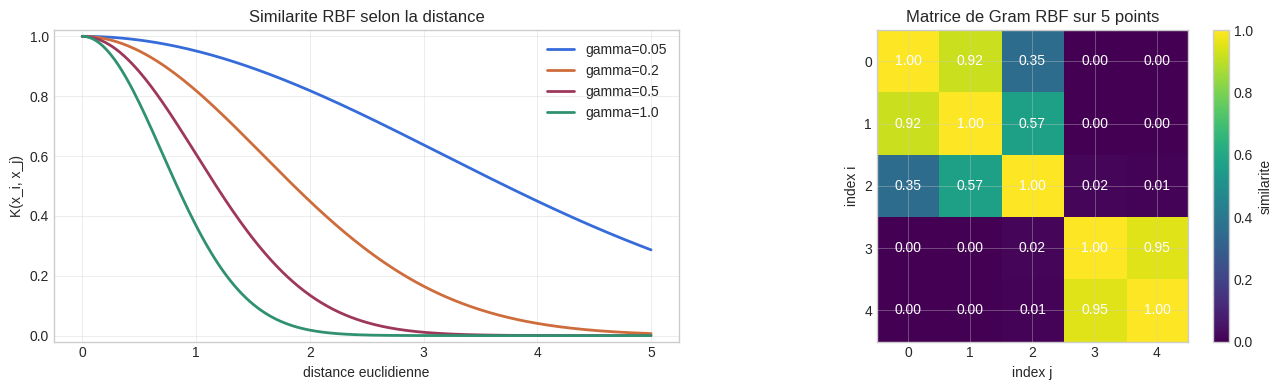

In [5]:
if not HAS_MATPLOTLIB:
    print("Graphe ignore: installez matplotlib pour afficher cette visualisation.")
else:
    distances = np.linspace(0, 5, 300)
    gammas = [0.05, 0.2, 0.5, 1.0]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    for gamma in gammas:
        similarities = np.exp(-gamma * distances ** 2)
        axes[0].plot(distances, similarities, label=f"gamma={gamma}", linewidth=2)
    axes[0].set_title("Similarite RBF selon la distance")
    axes[0].set_xlabel("distance euclidienne")
    axes[0].set_ylabel("K(x_i, x_j)")
    axes[0].set_ylim(-0.02, 1.02)
    axes[0].legend()

    points_kernel = np.array([
        [0.0, 0.0],
        [0.4, 0.1],
        [1.2, 0.8],
        [3.0, 3.0],
        [3.3, 3.1],
    ])
    K_demo = NoyauRBF(gamma=0.5).matrice(points_kernel)
    im = axes[1].imshow(K_demo, cmap="viridis", vmin=0, vmax=1)
    axes[1].set_title("Matrice de Gram RBF sur 5 points")
    axes[1].set_xlabel("index j")
    axes[1].set_ylabel("index i")
    for i in range(K_demo.shape[0]):
        for j in range(K_demo.shape[1]):
            axes[1].text(j, i, f"{K_demo[i, j]:.2f}", ha="center", va="center", color="white")
    fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04, label="similarite")

    plt.tight_layout()
    plt.show()


<a id='4'></a>
## 4. L'algorithme SMO

### 4.1 Pourquoi SMO ?

Le problème dual du SVM est un problème de **programmation quadratique (QP)**. Les solveurs QP génériques ont une complexité $O(n^3)$ en mémoire et temps. Pour MNIST (60 000 images), c'est inenvisageable dû au fait que nous n'aillons pas en python toutes les optimisations qui sont codé en C++ pour `scikit-learn ` par exemple..

**SMO** (Platt, 1998) décompose ce gros problème QP en sous-problèmes **analytiquement résolubles** de taille 2 : à chaque étape, on choisit deux multiplicateurs $(\lambda_i, \lambda_j)$ et on les optimise **à variables fixées**.

### 4.2 Structure de la classe SVM_SMO_Optimise

```
SVM_SMO_Optimise
├── Attributs clés :
│   ├── lambdas      : vecteur des multiplicateurs de Lagrange (n_samples,)
│   ├── b            : biais du classifieur
│   ├── K            : matrice de Gram pré-calculée (n_samples × n_samples)
│   ├── errors       : cache f(xi) - yi pour éviter les recalculs
│   └── support_indices_ : indices des vecteurs supports (λ > 0)
│
└── Méthodes :
    ├── fit(X, y)           : boucle SMO principale
    ├── decision_function(X): f(x) = Σ λi·yi·K(xi,x) + b
    └── predict(X)          : signe de decision_function
```

### 4.3 Détail de la mise à jour SMO

Pour la paire $(i, j)$, la mise à jour analytique de $\lambda_j$ est :

$$\lambda_j^{\text{new}} = \lambda_j^{\text{old}} - \frac{y_j (E_i - E_j)}{\eta}$$

avec $\eta = 2K_{ij} - K_{ii} - K_{jj} < 0$ (condition pour que l'objectif soit convexe).

On clippe ensuite dans les bornes $[L, H]$ pour maintenir les contraintes :

$$L = \begin{cases} \max(0, \lambda_j - \lambda_i) & \text{si } y_i \neq y_j \\ \max(0, \lambda_i + \lambda_j - C) & \text{si } y_i = y_j \end{cases}$$

Puis on met à jour $\lambda_i$ pour respecter la contrainte $\sum \lambda_i y_i = 0$ :

$$\lambda_i^{\text{new}} = \lambda_i^{\text{old}} + y_i y_j (\lambda_j^{\text{old}} - \lambda_j^{\text{new}})$$

### 4.4 Mise à jour du biais $b$

Après chaque mise à jour, on recalcule $b$ depuis les conditions KKT :
- Si $\lambda_i$ est dans $(0, C)$ : $b = b_1$ (calculé depuis le point $i$)
- Si $\lambda_j$ est dans $(0, C)$ : $b = b_2$ (calculé depuis le point $j$)
- Sinon : $b = (b_1 + b_2) / 2$

### 4.5 Cache des erreurs

Plutôt que de recalculer $E_i = f(x_i) - y_i$ à chaque itération (coûteux), on **maintient un cache** mis à jour après chaque modification des $\lambda$ :

$$\text{errors} \mathrel{+}= y_i \cdot \Delta\lambda_i \cdot K_{:,i} + y_j \cdot \Delta\lambda_j \cdot K_{:,j} + \Delta b$$

In [6]:
class SVM_SMO_Optimise:
    def __init__(
            self,
            noyau,
            C=1.0,
            tolerance=1e-3,
            max_passes=5,
            support_threshold=1e-5,
            random_state=42,
    ):
        self.noyau = noyau
        self.C = C                               # Paramètre de régularisation
        self.tolerance = tolerance               # Tolérance pour les violations KKT
        self.max_passes = max_passes             # Critère d'arrêt (passes sans changement)
        self.support_threshold = support_threshold  # λ > seuil → vecteur support
        self.rng = np.random.default_rng(random_state)

        # Attributs initialisés lors de fit()
        self.lambdas = None          # Multiplicateurs de Lagrange
        self.b = 0.0                 # Biais
        self.X_train = None          # Données d'entraînement
        self.y_train = None          # Labels d'entraînement
        self.K = None                # Matrice de Gram (pré-calculée)
        self.errors = None           # Cache des erreurs f(xi) - yi
        self.support_indices_ = None # Indices des vecteurs supports

    def _decision_interne(self):
        """f(x) = K · (λ * y) + b, vectorisé sur tous les points d'entraînement."""
        return self.K @ (self.lambdas * self.y_train) + self.b

    def _mettre_a_jour_cache_erreurs(self):
        """Recalcul complet du cache (utilisé lors de l'initialisation)."""
        self.errors = self._decision_interne() - self.y_train

    def _choisir_j(self, i, E_i):
        """
        Heuristique de sélection du 2ème multiplicateur j (heuristique de Platt).
        On cherche le j qui maximise |E_i - E_j| pour faire le plus grand pas possible.
        On privilégie les multiplicateurs non-bornés (sur la marge) car
        ils ont plus de chances de violer les KKT.
        """
        non_bornes = np.where(
            (self.lambdas > self.support_threshold)
            & (self.lambdas < self.C - self.support_threshold)
        )[0]
        candidats = non_bornes[non_bornes != i]

        # Repli: si aucun non-borné disponible, choisir parmi tous les points
        if candidats.size == 0:
            candidats = np.arange(self.y_train.shape[0])
            candidats = candidats[candidats != i]

        if candidats.size == 0:
            raise ValueError("SMO necessite au moins deux echantillons.")

        ecarts = np.abs(E_i - self.errors[candidats])
        meilleurs = candidats[ecarts == np.max(ecarts)]
        return int(self.rng.choice(meilleurs))  # Aléatoire si ex-aequo

    def _objectif_pair(self, i, j, lambda_i, lambda_j):
        """
        Valeur de l'objectif dual pour la paire (i,j) — utilisée quand
        eta >= 0 (cas dégénéré) pour choisir la meilleure borne L ou H.
        """
        y_i = self.y_train[i]
        y_j = self.y_train[j]
        return (
                lambda_i
                + lambda_j
                - 0.5 * self.K[i, i] * lambda_i ** 2
                - 0.5 * self.K[j, j] * lambda_j ** 2
                - y_i * y_j * self.K[i, j] * lambda_i * lambda_j
        )

    def fit(self, X, y):
        """
        Boucle SMO principale.

        Critère d'arrêt : 'max_passes' passes consécutives sans mise à jour.
        À chaque itération, on parcourt tous les points dans un ordre aléatoire
        et on tente d'optimiser la paire (i, j) si i viole les KKT.
        """
        self.X_train = np.asarray(X, dtype=np.float64)
        self.y_train = np.asarray(y, dtype=np.float64)
        n_samples = self.X_train.shape[0]

        if n_samples < 2:
            raise ValueError("Il faut au moins deux echantillons pour entrainer le SVM.")

        # Pré-calcul de la matrice de Gram complète (coûteux mais fait une seule fois)
        self.K = self.noyau.matrice(self.X_train)
        self.lambdas = np.zeros(n_samples, dtype=np.float64)  # Init λ = 0
        self.b = 0.0
        # Init erreurs: f(xi)=b=0, donc E_i = 0 - yi = -yi
        self.errors = -self.y_train.copy()

        passes = 0  # Compteur de passes sans changement
        iteration = 0

        while passes < self.max_passes:
            num_changed_lambdas = 0
            ordre = self.rng.permutation(n_samples)  # Ordre aléatoire

            for i in ordre:
                E_i = self.errors[i]
                y_i = self.y_train[i]
                lambda_i_old = self.lambdas[i]

                # --- Vérification de la violation KKT ---
                # Un point viole KKT si y_i * f(x_i) < 1 alors que λ_i < C
                # (il devrait être plus loin de la marge)
                # ou y_i * f(x_i) > 1 alors que λ_i > 0
                # (il n'est pas vecteur support mais est traité comme tel)
                viole_kkt = (
                                    y_i * E_i < -self.tolerance and lambda_i_old < self.C
                            ) or (
                                    y_i * E_i > self.tolerance and lambda_i_old > 0
                            )

                if not viole_kkt:
                    continue  # Ce point est optimal, on passe au suivant

                # --- Sélection de j via l'heuristique de max |E_i - E_j| ---
                j = self._choisir_j(i, E_i)
                E_j = self.errors[j]
                y_j = self.y_train[j]
                lambda_j_old = self.lambdas[j]

                # --- Calcul des bornes L et H ---
                if y_i != y_j:
                    L = max(0.0, lambda_j_old - lambda_i_old)
                    H = min(self.C, self.C + lambda_j_old - lambda_i_old)
                else:
                    L = max(0.0, lambda_i_old + lambda_j_old - self.C)
                    H = min(self.C, lambda_i_old + lambda_j_old)

                if np.isclose(L, H):
                    continue  # Pas de marge d'optimisation

                # --- Calcul de eta ---
                k_ii = self.K[i, i]
                k_jj = self.K[j, j]
                k_ij = self.K[i, j]
                eta = 2.0 * k_ij - k_ii - k_jj  # Doit être < 0 (problème convexe)

                if eta < 0:
                    # Cas normal: mise à jour analytique
                    lambda_j_new = lambda_j_old - y_j * (E_i - E_j) / eta
                    lambda_j_new = np.clip(lambda_j_new, L, H)  # Respect des contraintes
                else:
                    # Cas dégénéré (eta >= 0): évaluation aux bornes
                    lambda_i_L = lambda_i_old + y_i * y_j * (lambda_j_old - L)
                    lambda_i_H = lambda_i_old + y_i * y_j * (lambda_j_old - H)
                    objectif_L = self._objectif_pair(i, j, lambda_i_L, L)
                    objectif_H = self._objectif_pair(i, j, lambda_i_H, H)

                    if objectif_L > objectif_H + self.tolerance:
                        lambda_j_new = L
                    elif objectif_H > objectif_L + self.tolerance:
                        lambda_j_new = H
                    else:
                        continue

                # --- Vérification que le changement est significatif ---
                if abs(lambda_j_new - lambda_j_old) < self.support_threshold:
                    continue

                # --- Mise à jour de λ_i (contrainte Σ λ_i y_i = 0) ---
                lambda_i_new = lambda_i_old + y_i * y_j * (lambda_j_old - lambda_j_new)
                lambda_i_new = np.clip(lambda_i_new, 0.0, self.C)

                # --- Mise à jour du biais b depuis les conditions KKT ---
                b_old = self.b
                b1 = self.b - E_i - y_i * (lambda_i_new - lambda_i_old) * k_ii \
                     - y_j * (lambda_j_new - lambda_j_old) * k_ij
                b2 = self.b - E_j - y_i * (lambda_i_new - lambda_i_old) * k_ij \
                     - y_j * (lambda_j_new - lambda_j_old) * k_jj

                if self.support_threshold < lambda_i_new < self.C - self.support_threshold:
                    self.b = b1  # Point i sur la marge → KKT exact
                elif self.support_threshold < lambda_j_new < self.C - self.support_threshold:
                    self.b = b2  # Point j sur la marge → KKT exact
                else:
                    self.b = (b1 + b2) / 2.0  # Aucun sur la marge → moyenne

                # --- Application des nouvelles valeurs ---
                self.lambdas[i] = lambda_i_new
                self.lambdas[j] = lambda_j_new

                # --- Mise à jour incrémentale du cache des erreurs ---
                # Plus efficace qu'un recalcul complet O(n)
                delta_i = lambda_i_new - lambda_i_old
                delta_j = lambda_j_new - lambda_j_old
                delta_b = self.b - b_old
                self.errors += (
                        y_i * delta_i * self.K[:, i]
                        + y_j * delta_j * self.K[:, j]
                        + delta_b
                )

                num_changed_lambdas += 1

            iteration += 1
            # Si aucun λ n'a changé cette passe, on incrémente le compteur d'arrêt
            if num_changed_lambdas == 0:
                passes += 1
            else:
                passes = 0  # Un changement → on repart

        # Mémorisation des vecteurs supports (λ_i > seuil)
        self.support_indices_ = np.where(self.lambdas > self.support_threshold)[0]
        return self

    def decision_function(self, X):
        """
        Calcule f(x) = Σ_{i∈SV} λ_i · y_i · K(x_i, x) + b
        Seuls les vecteurs supports contribuent → prédiction rapide.
        """
        if self.support_indices_ is None:
            raise RuntimeError("Le modele doit etre entraine avant la prediction.")

        X = np.asarray(X, dtype=np.float64)
        sv = self.support_indices_
        # On calcule la matrice de noyau uniquement entre X_test et les SVs
        K_test = self.noyau.matrice(X, self.X_train[sv])
        coefficients = self.lambdas[sv] * self.y_train[sv]  # λ_i * y_i
        return K_test @ coefficients + self.b

    def predict(self, X):
        """Prédit la classe (+1 ou -1) selon le signe de f(x)."""
        scores = self.decision_function(X)
        return np.where(scores >= 0.0, 1.0, -1.0)


print("Classe SVM_SMO_Optimise définie ")
print()
print("Vérification rapide sur données synthétiques...")

# Test rapide sur données séparables
np.random.seed(0)
X_pos = np.random.randn(20, 2) + 2
X_neg = np.random.randn(20, 2) - 2
X_test_svm = np.vstack([X_pos, X_neg])
y_test_svm = np.array([1.0]*20 + [-1.0]*20)

noyau_test = NoyauRBF(gamma=0.5)
svm_test = SVM_SMO_Optimise(noyau=noyau_test, C=1.0, max_passes=5)
svm_test.fit(X_test_svm, y_test_svm)
preds = svm_test.predict(X_test_svm)
accuracy = np.mean(preds == y_test_svm) * 100
n_sv = len(svm_test.support_indices_)

print(f"Précision (données d'entraînement): {accuracy:.1f}%")
print(f"Nombre de vecteurs supports: {n_sv} / {len(y_test_svm)}")

Classe SVM_SMO_Optimise définie 

Vérification rapide sur données synthétiques...
Précision (données d'entraînement): 100.0%
Nombre de vecteurs supports: 17 / 40


<a id='5'></a>
## 5. Classification multi-classes : One-vs-One (OvO)
> Nous avons préféré l'approche « Un-contre-Un » car le temps d'entraînement d'un SVM augmente de façon quadratique avec la taille des données, ce qui rend la résolution de nombreux petits problèmes de classification beaucoup plus rapide que celle de quelques modèles massifs traitant l'intégralité du dataset en une seule fois.
### 5.1 Stratégies multi-classes pour SVM

Le SVM est intrinsèquement **binaire**. Pour des problèmes multi-classes (comme MNIST avec 10 classes), plusieurs stratégies existent :

| Stratégie | Nb de modèles | Avantages | Inconvénients |
|:---------:|:-------------:|:---------:|:-------------:|
| One-vs-All (OvA) | $K$ | Simple | Données déséquilibrées |
| **One-vs-One (OvO)** | $\binom{K}{2} = K(K-1)/2$ | Problèmes plus équilibrés | Plus de modèles |

Pour MNIST ($K=10$) : OvO entraîne $\binom{10}{2} = 45$ classifieurs binaires.

### 5.2 Phase de prédiction : vote majoritaire

Chaque classifieur "vote" pour l'une de ses deux classes. La classe avec le **plus de votes** gagne.

```
Exemple: 3 classes (A, B, C) — 3 modèles

  (A vs B) → vote A
  (A vs C) → vote A
  (B vs C) → vote C

  Votes: A=2, B=0, C=1  →  Prédiction finale: A ✓
```

In [7]:
class SVM_MultiClass_OvO:
    """
    Stratégie One-vs-One : entraîne un SVM binaire pour chaque paire de classes.
    La prédiction se fait par vote majoritaire.
    """
    def __init__(self, C=1.0, gamma=0.001, tolerance=1e-3, max_passes=3):
        self.C = C
        self.gamma = gamma
        self.tolerance = tolerance
        self.max_passes = max_passes
        self.modeles = {}     # Dict: (classe1, classe2) → SVM entraîné
        self.classes_ = None  # Tableau des classes uniques

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        # Génération de toutes les paires de classes
        paires = list(itertools.combinations(self.classes_, 2))
        total_modeles = len(paires)

        print(f"Demarrage de l'entrainement OvO: {total_modeles} modeles a entrainer.")

        for idx, (c1, c2) in enumerate(paires):
            print(f"  -> Entrainement {idx + 1}/{total_modeles} : Classe {c1} vs Classe {c2}", end="\r")

            # 1. Isoler uniquement les données des deux classes concernées
            masque = (y == c1) | (y == c2)
            X_pair = X[masque]
            y_pair = y[masque]

            # 2. Binarisation des labels: c1 → +1, c2 → -1
            y_binaire = np.where(y_pair == c1, 1.0, -1.0)

            # 3. Entraînement du SVM binaire sur cette paire
            noyau = NoyauRBF(gamma=self.gamma)
            modele = SVM_SMO_Optimise(
                noyau=noyau,
                C=self.C,
                tolerance=self.tolerance,
                max_passes=self.max_passes
            )
            modele.fit(X_pair, y_binaire)

            # 4. Stockage du modèle avec la clé = paire de classes
            self.modeles[(c1, c2)] = modele

        print("\nEntrainement de tous les modeles termine !")

    def predict(self, X):
        """
        Vote majoritaire sur tous les classifieurs binaires.
        votes[i, k] = nombre de votes pour la classe k sur le sample i.
        """
        n_samples = X.shape[0]
        votes = np.zeros((n_samples, len(self.classes_)))
        class_to_idx = {c: i for i, c in enumerate(self.classes_)}

        for (c1, c2), modele in self.modeles.items():
            predictions_binaires = modele.predict(X)  # +1 ou -1

            for i in range(n_samples):
                if predictions_binaires[i] == 1.0:
                    votes[i, class_to_idx[c1]] += 1  # Vote pour c1
                else:
                    votes[i, class_to_idx[c2]] += 1  # Vote pour c2

        # La classe gagnante est celle avec le plus de votes
        indices_gagnants = np.argmax(votes, axis=1)
        return self.classes_[indices_gagnants]


print("Classe SVM_MultiClass_OvO définie ")
print()

# --- Illustration du vote OvO ---
print("Illustration du vote OvO pour 3 classes:")
classes_exemple = np.array(['A', 'B', 'C'])
paires_exemple = list(itertools.combinations(classes_exemple, 2))
print(f"  Paires générées: {paires_exemple}")
print(f"  Nombre de classifieurs: {len(paires_exemple)}")

print()
print("Pour MNIST (10 classes):")
from math import comb
print(f"  Nombre de classifieurs OvO = C(10,2) = {comb(10,2)} modèles")

Classe SVM_MultiClass_OvO définie 

Illustration du vote OvO pour 3 classes:
  Paires générées: [(np.str_('A'), np.str_('B')), (np.str_('A'), np.str_('C')), (np.str_('B'), np.str_('C'))]
  Nombre de classifieurs: 3

Pour MNIST (10 classes):
  Nombre de classifieurs OvO = C(10,2) = 45 modèles


<a id='6'></a>
## 6. Chargement et préparation des données MNIST

### 6.1 Le dataset MNIST

MNIST contient des images de **chiffres manuscrits** (0 à 9) en niveaux de gris :
- **Entraînement** : 60 000 images
- **Test** : 10 000 images
- **Format** : 28×28 pixels = **784 features** par image (valeurs 0–255)

Ici, on utilise une version réduite (`mnist_train_32.csv` / `mnist_test_32.csv`) dans un format CSV où chaque ligne est une image aplatie avec son label.

### 6.2 Pourquoi sous-échantillonner ?

La complexité de SMO est approximativement $O(n^2)$ en temps et mémoire (à cause de la matrice de Gram). Sur 60 000 images :
- La matrice K aurait $60000^2 = 3.6 \times 10^9$ entrées → ~27 Go de RAM !
- SMO n'est pas parallélisé en Python pur

On se limite donc à **5 000 images** pour l'entraînement et **1 000** pour le test.

In [8]:
def charger_csv_mnist(nom_fichier):
    """
    Cherche le fichier CSV dans plusieurs emplacements relatifs courants.
    Retourne un DataFrame pandas.
    """
    dossier_script = Path(".").resolve()
    candidats = [
        dossier_script / ".." / "dataset" / nom_fichier,
        dossier_script / ".." / nom_fichier,
        Path(nom_fichier),
    ]
    for chemin in candidats:
        chemin = chemin.resolve()
        if chemin.exists():
            return pd.read_csv(chemin)
    chemins = ", ".join(str(c.resolve()) for c in candidats)
    raise FileNotFoundError(f"Fichier introuvable. Chemins testes: {chemins}")


def preparer_donnees_multiclasse(X_train, X_test):
    """
    Standardise les données : fit sur X_train, transform sur X_train et X_test.
    Retourne les données normalisées et le scaler (pour usage futur).
    """
    scaler = StandardScalerScratch()
    X_train_scaled = scaler.fit_transform(X_train)  # μ et σ calculés ici
    X_test_scaled = scaler.transform(X_test)         # Applique les mêmes μ et σ
    return X_train_scaled, X_test_scaled, scaler


print("Fonctions de chargement définies ")
print()
print("Pour charger vos données, assurez-vous que les fichiers suivants sont accessibles:")
print("  - mnist_train_32.csv")
print("  - mnist_test_32.csv")
print()
print("Format attendu: première colonne 'label' (0-9), reste = pixels aplatis")

Fonctions de chargement définies 

Pour charger vos données, assurez-vous que les fichiers suivants sont accessibles:
  - mnist_train_32.csv
  - mnist_test_32.csv

Format attendu: première colonne 'label' (0-9), reste = pixels aplatis


### 6.2 Visualisation du dataset utilisé

Avant l'entraînement, il faut vérifier deux choses concrètes : la répartition des classes et l'apparence des images après le redimensionnement en `32 x 32`. Une forte classe dominante biaiserait les métriques, et un problème de chargement serait visible immédiatement sur la grille d'images.


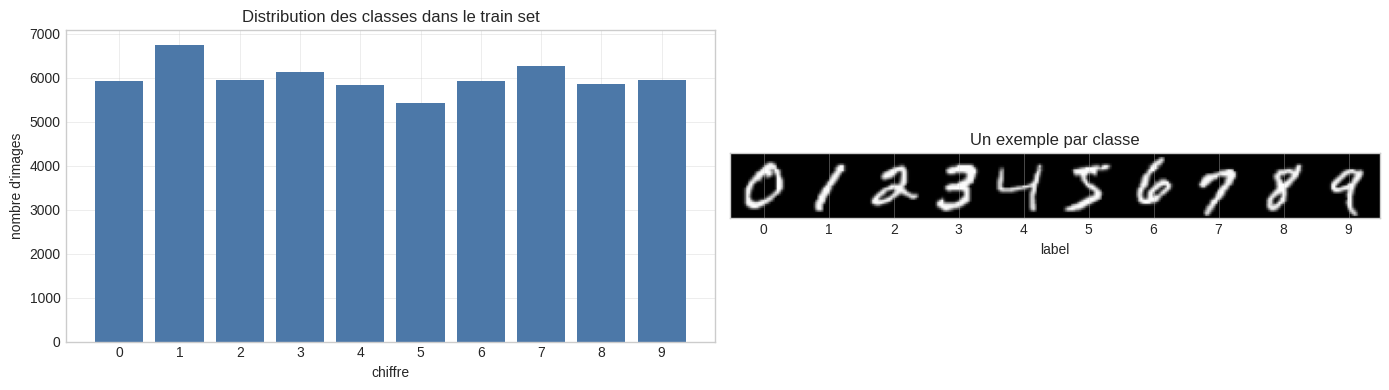

In [9]:
if not HAS_MATPLOTLIB:
    print("Graphe ignore: installez matplotlib pour afficher cette visualisation.")
else:
    try:
        df_train_viz = charger_csv_mnist("mnist_train_32.csv")
        y_viz = df_train_viz["label"].values
        X_viz = df_train_viz.drop("label", axis=1).values

        fig, axes = plt.subplots(1, 2, figsize=(14, 4))

        classes, counts = np.unique(y_viz, return_counts=True)
        axes[0].bar(classes, counts, color="#4c78a8")
        axes[0].set_title("Distribution des classes dans le train set")
        axes[0].set_xlabel("chiffre")
        axes[0].set_ylabel("nombre d'images")
        axes[0].set_xticks(classes)

        examples = []
        for digit in range(10):
            idx = np.where(y_viz == digit)[0]
            if idx.size > 0:
                examples.append(idx[0])

        grid = np.zeros((32, 32 * len(examples)))
        for col, idx in enumerate(examples):
            grid[:, col * 32:(col + 1) * 32] = X_viz[idx].reshape(32, 32)

        axes[1].imshow(grid, cmap="gray")
        axes[1].set_title("Un exemple par classe")
        axes[1].set_xticks([16 + 32 * i for i in range(len(examples))])
        axes[1].set_xticklabels([str(y_viz[idx]) for idx in examples])
        axes[1].set_yticks([])
        axes[1].set_xlabel("label")

        plt.tight_layout()
        plt.show()
    except FileNotFoundError:
        print("Visualisation ignoree: fichiers MNIST introuvables dans cet environnement.")


<a id='7'></a>
## 7. Entraînement et Évaluation

### Hyperparamètres choisis

| Hyperparamètre | Valeur | Justification |
|:--------------:|:------:|:-------------:|
| `C` | 1.0 | Valeur par défaut, bon équilibre marge/erreurs |
| `gamma` | 0.001 | Petit gamma → frontière lisse, adapté à MNIST |
| `max_passes` | 3 | Réduit pour accélérer (au détriment d'un peu de précision) |
| `N_TRAIN` | 5 000 | Compromis temps de calcul / précision |
| `N_TEST` | 1 000 | Évaluation sur un sous-ensemble représentatif |

In [10]:
if __name__ == "__main__" or True:  # True pour exécuter dans le notebook
    print("=== SVM Multi-Classes (OvO) From Scratch: MNIST ===")

    try:
        # --- Chargement ---
        print("Chargement des donnees...")
        df_train = charger_csv_mnist("mnist_train_32.csv")
        df_test  = charger_csv_mnist("mnist_test_32.csv")

        y_train_brut = df_train["label"].values
        X_train_brut = df_train.drop("label", axis=1).values
        y_test_brut  = df_test["label"].values
        X_test_brut  = df_test.drop("label", axis=1).values

        print(f"Données chargées: {X_train_brut.shape[0]} train, {X_test_brut.shape[0]} test")
        print(f"Dimensions des images: {X_train_brut.shape[1]} pixels par image")
        print(f"Classes présentes: {np.unique(y_train_brut)}")

        # --- Standardisation ---
        print("\nStandardisation des donnees...")
        X_train_scaled, X_test_scaled, _ = preparer_donnees_multiclasse(
            X_train_brut, X_test_brut
        )

        # --- Sous-échantillonnage ---
        N_SAMPLES_TRAIN = 3000
        N_SAMPLES_TEST  = 1000

        X_train_sub = X_train_scaled[:N_SAMPLES_TRAIN]
        y_train_sub = y_train_brut[:N_SAMPLES_TRAIN]
        X_test_sub  = X_test_scaled[:N_SAMPLES_TEST]
        y_test_sub  = y_test_brut[:N_SAMPLES_TEST]

        print(f"Sous-ensemble: {N_SAMPLES_TRAIN} train, {N_SAMPLES_TEST} test")

        # --- Entraînement OvO ---
        print(f"\nEntrainement sur {N_SAMPLES_TRAIN} images...")
        modele_multiclasse = SVM_MultiClass_OvO(
            C=1.0,
            gamma=0.001,
            max_passes=3
        )
        modele_multiclasse.fit(X_train_sub, y_train_sub)

        # --- Prédiction et évaluation ---
        print(f"Prediction sur {N_SAMPLES_TEST} images test...")
        predictions = modele_multiclasse.predict(X_test_sub)

        precision = np.mean(predictions == y_test_sub) * 100.0
        print(f"\n>>> Precision test globale (10 classes): {precision:.2f}% <<<")

    except FileNotFoundError as e:
        print(f"[INFO] Fichiers MNIST non trouvés dans cet environnement.")
        print(f"       Veuillez placer mnist_train_32.csv et mnist_test_32.csv")
        print(f"       dans le répertoire courant ou dans ../dataset/")

=== SVM Multi-Classes (OvO) From Scratch: MNIST ===
Chargement des donnees...
Données chargées: 60000 train, 10000 test
Dimensions des images: 1024 pixels par image
Classes présentes: [0 1 2 3 4 5 6 7 8 9]

Standardisation des donnees...
Sous-ensemble: 3000 train, 1000 test

Entrainement sur 3000 images...
Demarrage de l'entrainement OvO: 45 modeles a entrainer.
  -> Entrainement 45/45 : Classe 8 vs Classe 9
Entrainement de tous les modeles termine !
Prediction sur 1000 images test...

>>> Precision test globale (10 classes): 91.30% <<<


### 7.1 Visualisation des performances

La précision globale donne une seule valeur, mais elle ne dit pas quelles classes posent problème. La matrice de confusion montre les confusions chiffre par chiffre, et la précision par classe révèle si le modèle fonctionne uniformément ou s'il dépend surtout de quelques classes faciles.


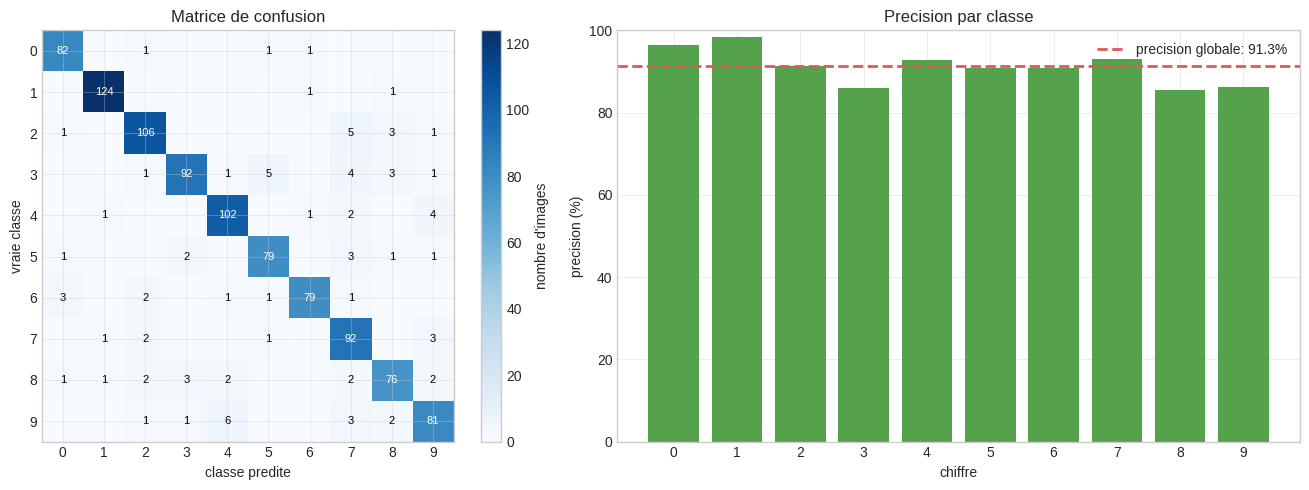

In [11]:
if not HAS_MATPLOTLIB:
    print("Graphe ignore: installez matplotlib pour afficher cette visualisation.")
else:
    if "predictions" in globals() and "y_test_sub" in globals():
        labels = np.arange(10)
        confusion = np.zeros((10, 10), dtype=int)
        for true_label, pred_label in zip(y_test_sub, predictions):
            confusion[int(true_label), int(pred_label)] += 1

        per_class_total = confusion.sum(axis=1)
        per_class_correct = np.diag(confusion)
        per_class_accuracy = np.divide(
            per_class_correct,
            per_class_total,
            out=np.zeros_like(per_class_correct, dtype=float),
            where=per_class_total != 0,
        ) * 100

        fig, axes = plt.subplots(1, 2, figsize=(15, 5))

        im = axes[0].imshow(confusion, cmap="Blues")
        axes[0].set_title("Matrice de confusion")
        axes[0].set_xlabel("classe predite")
        axes[0].set_ylabel("vraie classe")
        axes[0].set_xticks(labels)
        axes[0].set_yticks(labels)
        for i in labels:
            for j in labels:
                if confusion[i, j] > 0:
                    color = "white" if confusion[i, j] > confusion.max() * 0.55 else "black"
                    axes[0].text(j, i, confusion[i, j], ha="center", va="center", color=color, fontsize=8)
        fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04, label="nombre d'images")

        axes[1].bar(labels, per_class_accuracy, color="#54a24b")
        axes[1].axhline(precision, color="#e45756", linestyle="--", linewidth=2, label=f"precision globale: {precision:.1f}%")
        axes[1].set_title("Precision par classe")
        axes[1].set_xlabel("chiffre")
        axes[1].set_ylabel("precision (%)")
        axes[1].set_xticks(labels)
        axes[1].set_ylim(0, 100)
        axes[1].legend()

        plt.tight_layout()
        plt.show()
    else:
        print("Executez d'abord la cellule d'entrainement/evaluation pour afficher ces graphes.")


### 7.2 Analyse des vecteurs supports

Dans un SVM, seuls les vecteurs supports participent directement à la prédiction. Pour le One-vs-One, chaque paire de classes apprend son propre ensemble de vecteurs supports. Un nombre élevé indique souvent une séparation plus difficile entre les deux chiffres concernés.


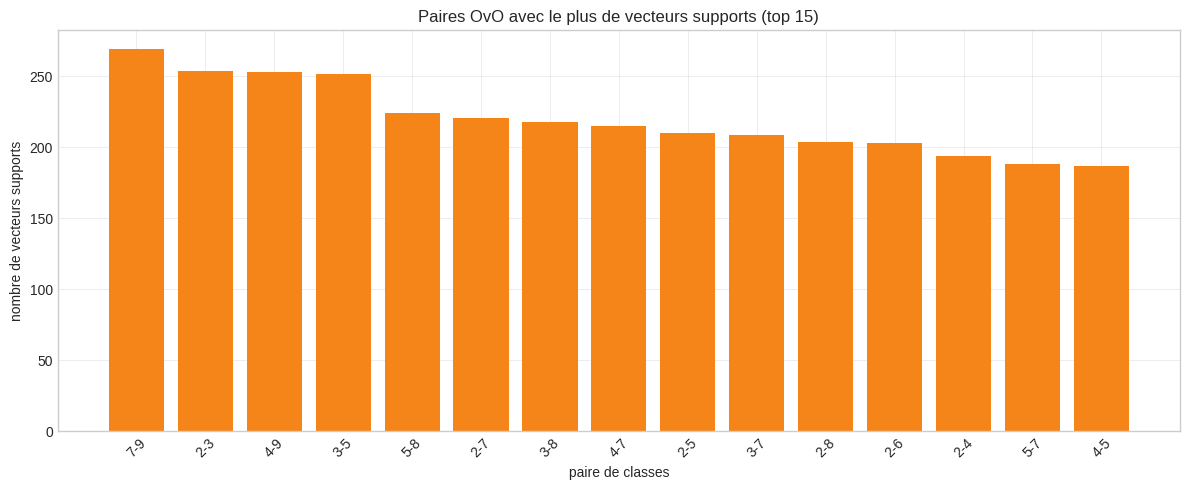

In [12]:
if not HAS_MATPLOTLIB:
    print("Graphe ignore: installez matplotlib pour afficher cette visualisation.")
else:
    if "modele_multiclasse" in globals() and hasattr(modele_multiclasse, "modeles") and modele_multiclasse.modeles:
        pair_labels = []
        support_counts = []

        for (c1, c2), modele in sorted(modele_multiclasse.modeles.items()):
            pair_labels.append(f"{c1}-{c2}")
            support_counts.append(len(modele.support_indices_))

        top_n = min(15, len(pair_labels))
        order = np.argsort(support_counts)[::-1][:top_n]

        fig, ax = plt.subplots(figsize=(12, 5))
        ax.bar(np.array(pair_labels)[order], np.array(support_counts)[order], color="#f58518")
        ax.set_title(f"Paires OvO avec le plus de vecteurs supports (top {top_n})")
        ax.set_xlabel("paire de classes")
        ax.set_ylabel("nombre de vecteurs supports")
        ax.tick_params(axis="x", rotation=45)

        plt.tight_layout()
        plt.show()
    else:
        print("Executez d'abord l'entrainement OvO pour analyser les vecteurs supports.")


<a id='8'></a>
## 8. Bilan et Pistes d'amélioration

### 8.1 Ce que ce code implémente from scratch

| Composant | Détail |
|:---------:|:------:|
| StandardScaler | Normalisation μ=0, σ=1 avec gestion des features constantes |
| Noyau RBF | Calcul vectorisé via l'identité $\|a-b\|^2 = \|a\|^2+\|b\|^2-2a^Tb$ |
| SMO | Sélection par violation KKT + heuristique max |E_i-E_j|, cache des erreurs |
| OvO | 45 classifieurs binaires + vote majoritaire |

### 8.2 Complexité computationnelle

| Étape | Complexité |
|:-----:|:----------:|
| Calcul matrice de Gram | $O(n^2 d)$ |
| Stockage matrice de Gram | $O(n^2)$ mémoire |
| Une itération SMO | $O(n)$ (grâce au cache des erreurs) |
| Prédiction | $O(n_{SV} \cdot d)$ par point |

### 8.3 Résultats attendus

Avec les hyperparamètres choisis (2 000 samples, C=1.0, γ=0.001) :
- Précision attendue : **~85–90%** sur MNIST 10 classes
- Les SVMs sklearn sur MNIST complet atteignent ~98% (avec optimisation)

### 8.4 Pistes d'amélioration

**Pour gagner en précision :**
- Augmenter `N_SAMPLES_TRAIN` (plus de données → meilleur modèle)
- Tuning des hyperparamètres `C` et `gamma` par validation croisée
- Augmenter `max_passes` pour une convergence plus complète

**Pour gagner en vitesse :**
- Utiliser Numba/Cython pour les boucles critiques de SMO
- Implémenter le **Working Set Selection** de Joachims (SMO-2)
- Paralléliser les 45 entraînements OvO avec `multiprocessing`
- Remplacer SMO par LIBSVM (binding Python via sklearn)

In [13]:
# Résumé de l'architecture
print("╔══════════════════════════════════════════════════════╗")
print("║          RÉSUMÉ DE L'IMPLÉMENTATION SVM OvO          ║")
print("╠══════════════════════════════════════════════════════╣")
print("║  1. StandardScalerScratch  → Normalisation           ║")
print("║  2. NoyauRBF               → Similarité vectorisée   ║")
print("║  3. SVM_SMO_Optimise       → Classifieur binaire     ║")
print("║     ├─ Matrice de Gram pré-calculée                  ║")
print("║     ├─ Cache des erreurs mis à jour incrémentalement ║")
print("║     ├─ Heuristique KKT + max |Ei - Ej|               ║")
print("║     └─ Prédiction via vecteurs supports uniquement   ║")
print("║  4. SVM_MultiClass_OvO     → 45 classifieurs MNIST   ║")
print("║     ├─ Paires: itertools.combinations(10 classes, 2) ║")
print("║     └─ Vote majoritaire pour la prédiction finale    ║")
print("╚══════════════════════════════════════════════════════╝")

╔══════════════════════════════════════════════════════╗
║          RÉSUMÉ DE L'IMPLÉMENTATION SVM OvO          ║
╠══════════════════════════════════════════════════════╣
║  1. StandardScalerScratch  → Normalisation           ║
║  2. NoyauRBF               → Similarité vectorisée   ║
║  3. SVM_SMO_Optimise       → Classifieur binaire     ║
║     ├─ Matrice de Gram pré-calculée                  ║
║     ├─ Cache des erreurs mis à jour incrémentalement ║
║     ├─ Heuristique KKT + max |Ei - Ej|               ║
║     └─ Prédiction via vecteurs supports uniquement   ║
║  4. SVM_MultiClass_OvO     → 45 classifieurs MNIST   ║
║     ├─ Paires: itertools.combinations(10 classes, 2) ║
║     └─ Vote majoritaire pour la prédiction finale    ║
╚══════════════════════════════════════════════════════╝
